# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [ ]:
import os
import numpy as np
import keras
from keras import layers
from keras.utils import PyDataset
import tensorflow as tf


We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [ ]:
STL10_CACHE = os.path.join(os.getcwd(), "stl10_data")
os.makedirs(STL10_CACHE, exist_ok=True)

def download_and_load_stl10():
    path = tf.keras.utils.get_file(
        fname="stl10_binary.tar.gz",
        origin="http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz",
        extract=True,
        cache_dir=STL10_CACHE,
        cache_subdir=".",
    )

    base_dir = os.path.dirname(path)
    candidate_dirs = [
        os.path.join(base_dir, "stl10_binary_extracted", "stl10_binary"),
        os.path.join(base_dir, "stl10_binary"),
    ]
    filepath = None
    for data_dir in candidate_dirs:
        candidate = os.path.join(data_dir, "unlabeled_X.bin")
        if os.path.exists(candidate):
            filepath = candidate
            break

    if filepath is None:
        raise FileNotFoundError("Could not find STL-10 unlabeled_X.bin after extraction.")

    print(f"Loading data from: {filepath}")

    with open(filepath, "rb") as f:
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))
        images = np.transpose(images, (0, 3, 2, 1))

    return images

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        X = np.empty((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.empty((actual_batch_size, 96, 96, 3), dtype="float32")

        margin = (self.patch_size - self.crop_size) // 2

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx].astype("float32") / 255.0
            Y[i] = full_img
            patches = []

            for r in range(3):
                for c in range(3):
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


In [ ]:
# Trigger the download and loading
images = download_and_load_stl10()
print(f"Successfully loaded {images.shape[0]} images.")

Loading data from: /content/stl10_data/./stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 100000 images.


In [ ]:
print(images.shape)

(100000, 96, 96, 3)


In [ ]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [ ]:
BATCH_SIZE = 32

train_generator = PatchGenerator(train_images, batch_size=BATCH_SIZE)
val_generator = PatchGenerator(val_images, batch_size=BATCH_SIZE, shuffle=False)
test_generator = PatchGenerator(test_images, batch_size=BATCH_SIZE, shuffle=False)

print("Batch size:", BATCH_SIZE)
print("Train steps per epoch:", len(train_generator))
print("Validation steps:", len(val_generator))


Batch size: 32
Train steps per epoch: 2500
Validation steps: 313


Let us inspect the dataset.

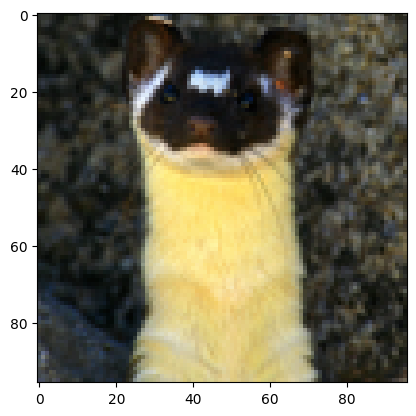

In [ ]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [ ]:
a,b = test_generator.__getitem__(1)

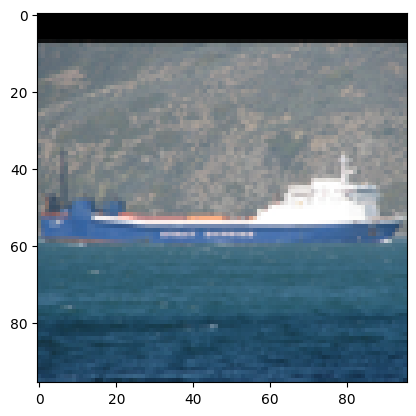

In [ ]:
plt.imshow(b[4])

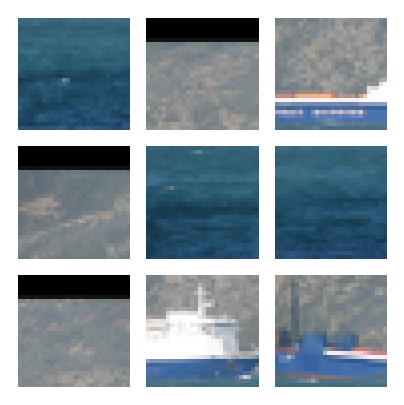

In [ ]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [ ]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [ ]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.18225479, shape=(), dtype=float32)
std: tf.Tensor(0.0016536539, shape=(), dtype=float32)


# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.





# Neural reconstruction model

I implemented an end-to-end neural reconstruction model that receives the 9 shuffled `28x28x3` patches and directly predicts the original `96x96x3` image. The problem is ambiguous because each patch is center-cropped from a larger grid cell, so the model has to infer both the spatial arrangement and the missing image content between patches.

The model is trained with Mean Absolute Error, which is also the required evaluation metric. I did not use pretrained weights, and the architecture stays below the 6 million trainable-parameter limit.


## Architectural choices

I used a shared convolutional encoder for the 9 input patches. The same encoder is applied independently to every patch, which keeps the number of parameters low and avoids making the representation depend on the arbitrary input order.

After encoding the patches, I use transformer-style self-attention over the patch tokens. This lets the model compare all patches with each other and learn global compatibility cues such as color, texture, object continuity, and background consistency.

To decode the image, I introduce 9 learned grid queries, one for each target position in the `3x3` layout. These queries attend to the patch tokens and produce a latent grid representation. A convolutional upsampling decoder then reconstructs the full `96x96x3` image.

I also add an attention-based patch canvas and a visible-patch mask to the decoder. This gives the network direct access to the observed patch pixels while still allowing it to learn how to fill the missing borders and uncertain regions. Since MAE is the final metric, I optimize the model directly with MAE; this can produce slightly smooth predictions in ambiguous areas, but it matches the scoring criterion.


In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()


## Model definition


In [ ]:
class LearnedGridQueries(layers.Layer):
    def __init__(self, num_queries=9, embed_dim=128, **kwargs):
        super().__init__(**kwargs)
        self.num_queries = num_queries
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.queries = self.add_weight(
            name="queries",
            shape=(self.num_queries, self.embed_dim),
            initializer="random_normal",
            trainable=True,
        )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        queries = tf.expand_dims(self.queries, axis=0)
        return tf.tile(queries, [batch_size, 1, 1])

    def get_config(self):
        config = super().get_config()
        config.update({"num_queries": self.num_queries, "embed_dim": self.embed_dim})
        return config


class AverageAttentionHeads(layers.Layer):
    def call(self, attention_scores):
        return tf.reduce_mean(attention_scores, axis=1)


class AttentionPatchCanvas96(layers.Layer):
    def call(self, inputs):
        assignment, patches = inputs
        ordered = tf.einsum("bgp,bphwc->bghwc", assignment, patches)

        b = tf.shape(ordered)[0]
        c = tf.shape(ordered)[4]
        ordered = tf.reshape(ordered, [b, 3, 3, 28, 28, c])
        ordered = tf.pad(ordered, [[0, 0], [0, 0], [0, 0], [2, 2], [2, 2], [0, 0]])
        ordered = tf.transpose(ordered, [0, 1, 3, 2, 4, 5])
        return tf.reshape(ordered, [b, 96, 96, c])


class AttentionPatchMask96(layers.Layer):
    def call(self, inputs):
        assignment, patches = inputs
        patch_mask = tf.ones_like(patches[..., :1])
        ordered = tf.einsum("bgp,bphwc->bghwc", assignment, patch_mask)

        b = tf.shape(ordered)[0]
        ordered = tf.reshape(ordered, [b, 3, 3, 28, 28, 1])
        ordered = tf.pad(ordered, [[0, 0], [0, 0], [0, 0], [2, 2], [2, 2], [0, 0]])
        ordered = tf.transpose(ordered, [0, 1, 3, 2, 4, 5])
        return tf.reshape(ordered, [b, 96, 96, 1])


def transformer_block(x, embed_dim=128, num_heads=4, ff_dim=None, dropout=0.1, name="tx"):
    if ff_dim is None:
        ff_dim = embed_dim * 2
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout,
        name=f"{name}_mha",
    )(x, x)
    x = layers.Add(name=f"{name}_attn_add")([x, attn])
    x = layers.LayerNormalization(name=f"{name}_attn_norm")(x)

    ff = layers.Dense(ff_dim, activation="gelu", name=f"{name}_ff_1")(x)
    ff = layers.Dropout(dropout, name=f"{name}_ff_dropout")(ff)
    ff = layers.Dense(embed_dim, name=f"{name}_ff_2")(ff)
    x = layers.Add(name=f"{name}_ff_add")([x, ff])
    return layers.LayerNormalization(name=f"{name}_ff_norm")(x)


def build_jigsaw_model(embed_dim=128, num_heads=4):
    inputs = keras.Input(shape=(9, 28, 28, 3), name="patches")

    patch_encoder = keras.Sequential(
        [
            layers.Input(shape=(28, 28, 3)),
            layers.Conv2D(32, 3, padding="same", activation="gelu"),
            layers.Conv2D(32, 3, padding="same", activation="gelu"),
            layers.Conv2D(64, 3, strides=2, padding="same", activation="gelu"),
            layers.Conv2D(64, 3, padding="same", activation="gelu"),
            layers.Conv2D(128, 3, strides=2, padding="same", activation="gelu"),
            layers.Conv2D(128, 3, padding="same", activation="gelu"),
            layers.Conv2D(96, 1, padding="same", activation="gelu", name="patch_channel_mix"),
            layers.GlobalAveragePooling2D(),
            layers.Dense(embed_dim),
        ],
        name="shared_patch_encoder",
    )

    tokens = layers.TimeDistributed(patch_encoder, name="encode_each_patch")(inputs)
    tokens = layers.LayerNormalization(name="token_norm")(tokens)
    tokens = transformer_block(tokens, embed_dim=embed_dim, num_heads=num_heads, name="patch_tx_1")
    tokens = transformer_block(tokens, embed_dim=embed_dim, num_heads=num_heads, name="patch_tx_2")

    queries = LearnedGridQueries(9, embed_dim, name="learned_grid_queries")(tokens)
    slots, attention_scores = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        name="grid_cross_attention",
    )(queries, tokens, tokens, return_attention_scores=True)
    assignment = AverageAttentionHeads(name="grid_patch_assignment")(
        attention_scores
    )
    slots = layers.Add(name="grid_slot_add")([queries, slots])
    slots = layers.LayerNormalization(name="grid_slot_norm")(slots)
    slots = transformer_block(slots, embed_dim=embed_dim, num_heads=num_heads, name="grid_tx")

    grid = layers.Reshape((3, 3, embed_dim), name="tokens_to_grid")(slots)

    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same", activation="gelu")(grid)
    x = layers.Conv2DTranspose(192, 3, strides=2, padding="same", activation="gelu")(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="gelu")(x)
    x = layers.Conv2DTranspose(96, 3, strides=2, padding="same", activation="gelu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="gelu")(x)
    canvas = AttentionPatchCanvas96(name="attention_patch_canvas_96")([assignment, inputs])
    visible_mask = AttentionPatchMask96(name="attention_patch_mask_96")([assignment, inputs])

    x = layers.Conv2D(64, 3, padding="same", activation="gelu")(x)
    x = layers.Concatenate(name="decoder_canvas_mask_fusion")([x, canvas, visible_mask])
    x = layers.Conv2D(64, 3, padding="same", activation="gelu", name="canvas_fusion_64")(x)
    x = layers.Conv2D(48, 3, padding="same", activation="gelu", name="decoder_detail_refine")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="gelu")(x)
    outputs = layers.Conv2D(3, 1, activation="sigmoid", dtype="float32", name="reconstruction")(x)

    return keras.Model(inputs, outputs, name="jigsaw_attention_decoder")


model = build_jigsaw_model()
model.summary()
print("Trainable parameters:", model.count_params())
assert model.count_params() < 6_000_000


Model: "jigsaw_attention_decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches             │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encode_each_patch   │ (None, 9, 128)    │    311,808 │ patches[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_norm          │ (None, 9, 128)    │        256 │ encode_each_patc… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_1_mha      │ (None, 9, 128)    │     66,048 │ token_norm[0][0], │
│ (MultiHeadAttentio… │                   │            │ token_norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_1_attn_add │ (None, 9, 128)    │          0 │ token_norm[0][0], │
│ (Add)               │                   │            │ patch_tx_1_mha[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_1_attn_no… │ (None, 9, 128)    │        256 │ patch_tx_1_attn_… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_1_ff_1     │ (None, 9, 256)    │     33,024 │ patch_tx_1_attn_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_1_ff_drop… │ (None, 9, 256)    │          0 │ patch_tx_1_ff_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_1_ff_2     │ (None, 9, 128)    │     32,896 │ patch_tx_1_ff_dr… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_1_ff_add   │ (None, 9, 128)    │          0 │ patch_tx_1_attn_… │
│ (Add)               │                   │            │ patch_tx_1_ff_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_1_ff_norm  │ (None, 9, 128)    │        256 │ patch_tx_1_ff_ad… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_2_mha      │ (None, 9, 128)    │     66,048 │ patch_tx_1_ff_no… │
│ (MultiHeadAttentio… │                   │            │ patch_tx_1_ff_no… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_2_attn_add │ (None, 9, 128)    │          0 │ patch_tx_1_ff_no… │
│ (Add)               │                   │            │ patch_tx_2_mha[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_2_attn_no… │ (None, 9, 128)    │        256 │ patch_tx_2_attn_… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_2_ff_1     │ (None, 9, 256)    │     33,024 │ patch_tx_2_attn_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_2_ff_drop… │ (None, 9, 256)    │          0 │ patch_tx_2_ff_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tx_2_ff_2     │ (None, 9, 128)    │     32,896 │ patch_tx_2_ff_dr

 Total params: 2,019,859 (7.71 MB)

 Trainable params: 2,019,859 (7.71 MB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 2019859


In [ ]:
def compile_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=1e-5,
            global_clipnorm=1.0,
        ),
        loss=keras.losses.MeanAbsoluteError(),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
        jit_compile=False,
    )
    return model


## Training procedure

I trained the model for 50 epochs on the full training set and selected the weights with the best validation MAE during this main training run. The final submitted weights are stored in `jigsaw_v2_best.weights.h5`.

For reproducibility, the notebook is configured with `TRAIN_FROM_SCRATCH = False`. In this mode, the architecture is built and the submitted weights are loaded directly, so the reconstruction examples and test-set evaluation can be run without repeating training. If the local weights file is not present, the same file can be downloaded from Google Drive using `gdown`.


In [ ]:
TRAIN_FROM_SCRATCH = False
GDOWN_FILE_ID = "185BouZlbTJKTpehJj7GvnmkRHqNCRuE_"

FINAL_WEIGHTS_PATH = "jigsaw_v2_best.weights.h5"
FULL_TRAIN_EPOCHS = 50


def ensure_gdown():
    try:
        import gdown
    except ImportError:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
        import gdown
    return gdown


def download_weights_if_needed(weights_path=FINAL_WEIGHTS_PATH, file_id=GDOWN_FILE_ID):
    if os.path.exists(weights_path):
        return weights_path

    if file_id == "PASTE_GOOGLE_DRIVE_FILE_ID_HERE":
        raise FileNotFoundError(
            f"{weights_path} was not found locally. Set GDOWN_FILE_ID to the Google Drive file id "
            "for the submitted weights file."
        )

    gdown = ensure_gdown()
    gdown.download(id=file_id, output=weights_path, quiet=False)

    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"gdown did not create {weights_path}. Check that the Drive file is shared.")

    return weights_path


training_callbacks = [
    keras.callbacks.ModelCheckpoint(
        FINAL_WEIGHTS_PATH,
        monitor="val_mae",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_mae",
        mode="min",
        factor=0.25,
        patience=3,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_mae",
        mode="min",
        patience=6,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.TerminateOnNaN(),
]

if TRAIN_FROM_SCRATCH:
    compile_model(model, learning_rate=5e-4)
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=FULL_TRAIN_EPOCHS,
        callbacks=training_callbacks,
    )

    best_full_val_mae = min(history.history["val_mae"])
    model.load_weights(FINAL_WEIGHTS_PATH)
    print("Best full-training validation MAE:", best_full_val_mae)
    print("Final weights saved to:", FINAL_WEIGHTS_PATH)
else:
    weights_path = download_weights_if_needed()
    model.load_weights(weights_path)
    print("Loaded submitted weights:", weights_path)


Loaded submitted weights: jigsaw_v2_best.weights.h5


## Training curves


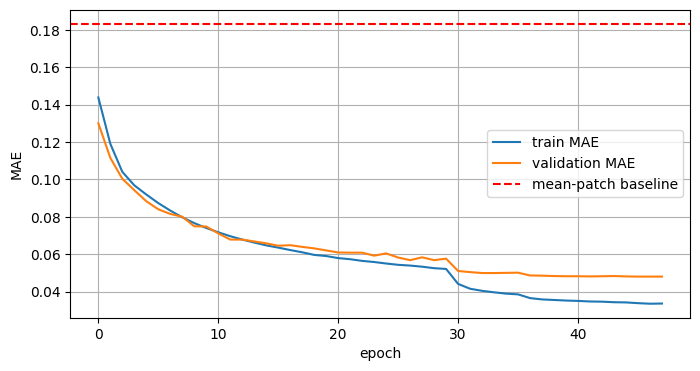

In [ ]:
SAVED_TRAIN_MAE = [
    0.1438, 0.1190, 0.1040, 0.0968, 0.0919, 0.0873, 0.0833, 0.0797,
    0.0766, 0.0740, 0.0717, 0.0696, 0.0678, 0.0662, 0.0647, 0.0635,
    0.0622, 0.0610, 0.0596, 0.0590, 0.0579, 0.0573, 0.0564, 0.0558,
    0.0550, 0.0543, 0.0539, 0.0533, 0.0525, 0.0521, 0.0441, 0.0415,
    0.0404, 0.0396, 0.0389, 0.0385, 0.0365, 0.0358, 0.0355, 0.0352,
    0.0350, 0.0347, 0.0346, 0.0343, 0.0342, 0.0338, 0.0335, 0.0336,
]
SAVED_VAL_MAE = [
    0.1300, 0.1115, 0.1003, 0.0942, 0.0883, 0.0840, 0.0815, 0.0800,
    0.0749, 0.0748, 0.0711, 0.0678, 0.0678, 0.0668, 0.0658, 0.0645,
    0.0648, 0.0639, 0.0631, 0.0620, 0.0609, 0.0608, 0.0608, 0.0592,
    0.0604, 0.0582, 0.0568, 0.0583, 0.0568, 0.0576, 0.0510, 0.0504,
    0.0499, 0.0499, 0.0500, 0.0501, 0.0486, 0.0485, 0.0483, 0.0482,
    0.0482, 0.0481, 0.0482, 0.0483, 0.0481, 0.0480, 0.0480, 0.0480,
]

if "history" in globals():
    train_mae = history.history["mae"]
    val_mae = history.history["val_mae"]
else:
    train_mae = SAVED_TRAIN_MAE
    val_mae = SAVED_VAL_MAE

plt.figure(figsize=(8, 4))
plt.plot(train_mae, label="train MAE")
plt.plot(val_mae, label="validation MAE")
plt.axhline(0.18321691, color="red", linestyle="--", label="mean-patch baseline")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()


## Qualitative reconstruction examples


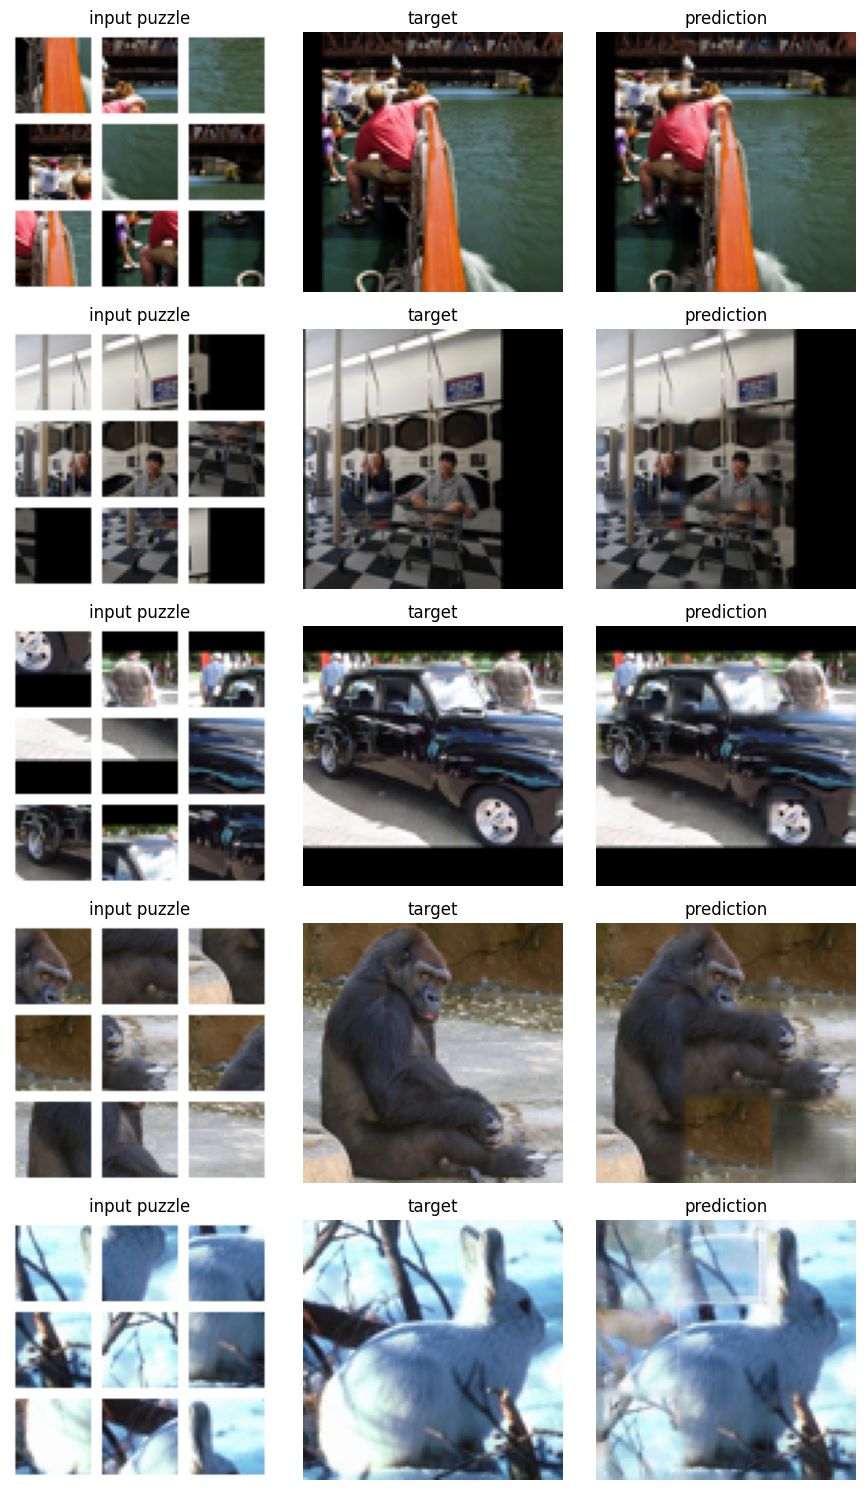

In [ ]:
def make_puzzle_canvas(patches, ordering=None):
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    canvas = np.ones((96, 96, 3), dtype=np.float32)
    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    for i in range(9):
        grid_pos = order[i]
        row = grid_pos // 3
        col = grid_pos % 3
        y_start = (row * cell_dim) + margin
        x_start = (col * cell_dim) + margin
        canvas[y_start : y_start + patch_dim, x_start : x_start + patch_dim] = patches[i]

    return canvas


def show_reconstruction(model, generator, n=5):
    patches, target = generator[0]
    pred = model.predict(patches[:n], verbose=0)

    plt.figure(figsize=(9, 3 * n))
    for i in range(n):
        plt.subplot(n, 3, 3 * i + 1)
        plt.imshow(make_puzzle_canvas(patches[i]))
        plt.title("input puzzle")
        plt.axis("off")

        plt.subplot(n, 3, 3 * i + 2)
        plt.imshow(target[i])
        plt.title("target")
        plt.axis("off")

        plt.subplot(n, 3, 3 * i + 3)
        plt.imshow(np.clip(pred[i], 0, 1))
        plt.title("prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


model.load_weights(FINAL_WEIGHTS_PATH)
show_reconstruction(model, test_generator, n=5)


## Test MAE and standard deviation

The following cell follows the same evaluation style as the baseline: MAE is computed over the test generator and the standard deviation is reported.


In [ ]:
model.load_weights(FINAL_WEIGHTS_PATH)

mae_values = []
for patches, targets in test_generator:
    predictions = model.predict(patches, verbose=0)
    batch_mae = np.mean(np.abs(predictions - targets), axis=(1, 2, 3))
    mae_values.extend(batch_mae)

mae_values = np.array(mae_values)

print("Per-image test MAE:", mae_values.mean())
print("Per-image test std:", mae_values.std())
print("Evaluated images:", len(mae_values))
print("Trainable parameters:", model.count_params())


Per-image test MAE: 0.04894268
Per-image test std: 0.04988722
Evaluated images: 10000
Trainable parameters: 2019859


## Weight download verification

---



The following cell checks that the submitted weights are compatible with the model definition. When `GDOWN_FILE_ID` is set, it also verifies that the Google Drive download works through `gdown`.


In [ ]:
fresh_model = build_jigsaw_model()

downloaded_weights_path = "gdown_jigsaw_v2_best.weights.h5"
if os.path.exists(downloaded_weights_path):
    os.remove(downloaded_weights_path)

gdown = ensure_gdown()
gdown.download(id=GDOWN_FILE_ID, output=downloaded_weights_path, quiet=False)
fresh_model.load_weights(downloaded_weights_path)
print("Weights downloaded with gdown and loaded correctly.")


Downloading...
From: https://drive.google.com/uc?id=185BouZlbTJKTpehJj7GvnmkRHqNCRuE_
To: /content/gdown_jigsaw_v2_best.weights.h5
100%|██████████| 40.8M/40.8M [00:00<00:00, 67.6MB/s]


Weights downloaded with gdown and loaded correctly.
